In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

import shap
from lime.lime_tabular import LimeTabularExplainer

In [2]:
data = pd.read_csv("dataset/german_credit_data.csv")

In [3]:
data.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [4]:
data.dtypes

status_account               str
month_duration             int64
credit_history               str
purpose                      str
credit_amount              int64
status_savings               str
years_employment             str
payment_to_income_ratio    int64
status_and_sex               str
secondary_obligor            str
residence_since            int64
collateral                   str
age                        int64
other_installment_plans      str
housing                      str
n_credits                  int64
job                          str
n_guarantors               int64
telephone                    str
is_foreign_worker            str
target                       str
dtype: object

In [5]:
data.isnull().sum()

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64

In [6]:
label_encoder = LabelEncoder()

object_columns = data.select_dtypes(include=['object']).columns

for column in object_columns:
    data[column] = label_encoder.fit_transform(data[column].astype(str))

C:\Users\Maryam-PC\AppData\Local\Temp\ipykernel_7424\1615266553.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = data.select_dtypes(include=['object']).columns


In [7]:
data.dtypes

status_account             int64
month_duration             int64
credit_history             int64
purpose                    int64
credit_amount              int64
status_savings             int64
years_employment           int64
payment_to_income_ratio    int64
status_and_sex             int64
secondary_obligor          int64
residence_since            int64
collateral                 int64
age                        int64
other_installment_plans    int64
housing                    int64
n_credits                  int64
job                        int64
n_guarantors               int64
telephone                  int64
is_foreign_worker          int64
target                     int64
dtype: object

In [8]:
X = data.drop('target', axis=1)
y = data['target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestClassifier()

In [11]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
predictions = model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.775


In [14]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.68      0.46      0.55        59
           1       0.80      0.91      0.85       141

    accuracy                           0.78       200
   macro avg       0.74      0.68      0.70       200
weighted avg       0.76      0.78      0.76       200



In [15]:
explainer = shap.TreeExplainer(model)

In [16]:
shap_values = explainer.shap_values(X_test)

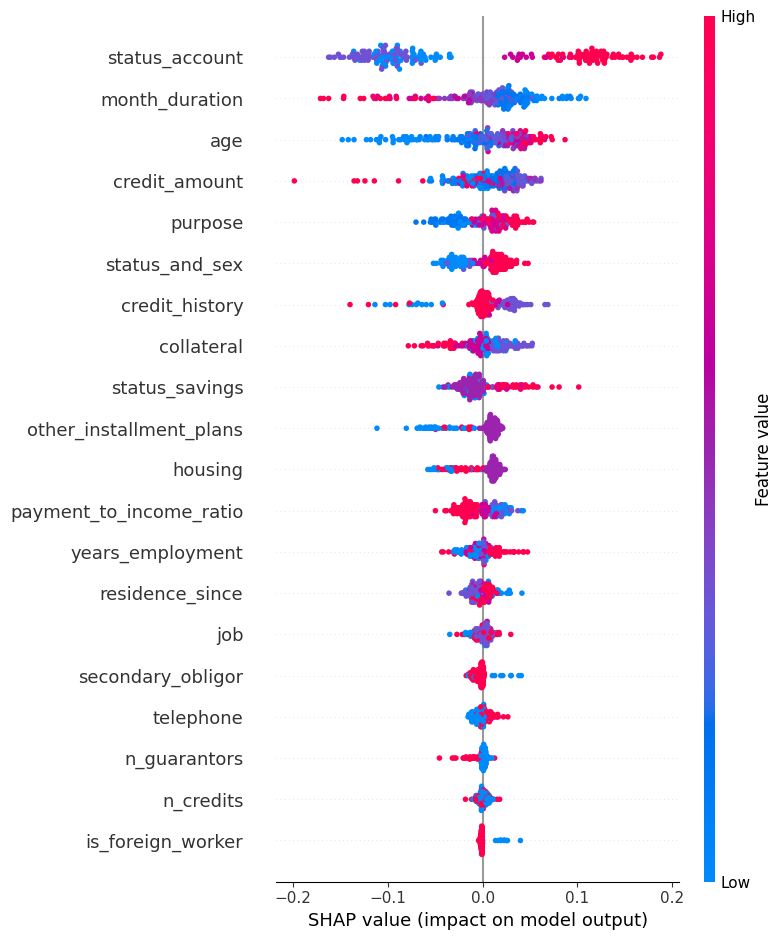

In [18]:
shap.summary_plot(shap_values[:, :, 1], X_test)

In [19]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    class_names=['bad', 'good'],
    mode='classification'
)

In [20]:
lime_exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict_proba
)

C:\Users\Maryam-PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [22]:
lime_exp.as_list()

[('0.00 < status_account <= 1.00', -0.12680797559917423),
 ('age <= 27.00', -0.08861503716163453),
 ('2333.00 < credit_amount <= 4154.50', 0.05324538713795658),
 ('status_and_sex <= 0.00', -0.036017866301945055),
 ('status_savings <= 2.00', -0.03560756762003857),
 ('other_installment_plans <= 1.00', 0.031838047374275626),
 ('4.00 < purpose <= 7.00', 0.030380508122801228),
 ('collateral <= 1.00', 0.025074378621785503),
 ('payment_to_income_ratio <= 2.00', 0.022007778626065053),
 ('housing <= 1.00', 0.020441575241622625)]

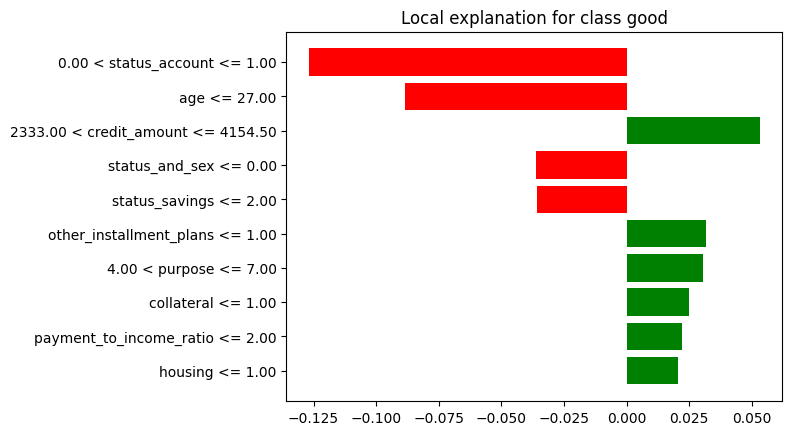

In [23]:
lime_exp.as_pyplot_figure()
plt.show()

In [24]:
data['status_and_sex'].value_counts()

status_and_sex
3    548
0    310
2     92
1     50
Name: count, dtype: int64